# PROCESAMIENTO de Visión por Computador — **INSPECTOR DE PANALES**
**Proyecto integrador – Fase de Preparación y Procesamiento de Datos**

##Parte 1

Configuración del proyecto
Librerías y utilidades
Escaneo de imágenes
EDA (conteos, histos, duplicados, outliers)

##Parte 2

Pipeline de limpieza con clase DataCleaner
Feature Engineering (Color, HOG y embeddings opcionales con ResNet18)
Balanceo de datos con SMOTE (opcional)
Data Augmentation (rotaciones, flips, jitter, etc.)
Partición estratificada en train/val/test
Baseline opcional con RandomForest
Próximos pasos

## 0. (Opcional) Montar Google Drive en Colab
Descomenta si trabajas en Google Colab y tus datos están en Drive.

In [37]:
 from google.colab import drive
 drive.mount('/content/drive')
 %cd /content/drive/MyDrive

# (Descomenta si necesitas instalar paquetes en Colab)
 !pip install opencv-python pillow scikit-image imagehash imbalanced-learn torch torchvision --quiet


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive


## 1. Carga dataset & Visualizacion
Preparar rutas y dataset con validaciones y partición dinámica

In [38]:
from pathlib import Path

DATA_DIR = Path("data")
CLEAN_DIR = Path("dataset_clean")
SPLIT_DIR = Path("dataset_split")
FEATURES_DIR = Path("features")
OUTPUTS_DIR = Path("outputs")

IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".tif",".tiff"}
RESIZE_HW = (224, 224)
P_LOW, P_HIGH = 5, 95
TEST_SIZE = 0.15
VAL_SIZE  = 0.15
RANDOM_SEED = 42

USE_PHASH = True
USE_EMBEDDINGS = False
EMBEDDINGS_BACKBONE = "resnet18"
SAVE_FIGS = True

for d in [CLEAN_DIR, SPLIT_DIR, FEATURES_DIR, OUTPUTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())


DATA_DIR: /content/drive/MyDrive/data


[Guardado] outputs/viz_grid_imagenes_cargadas.png


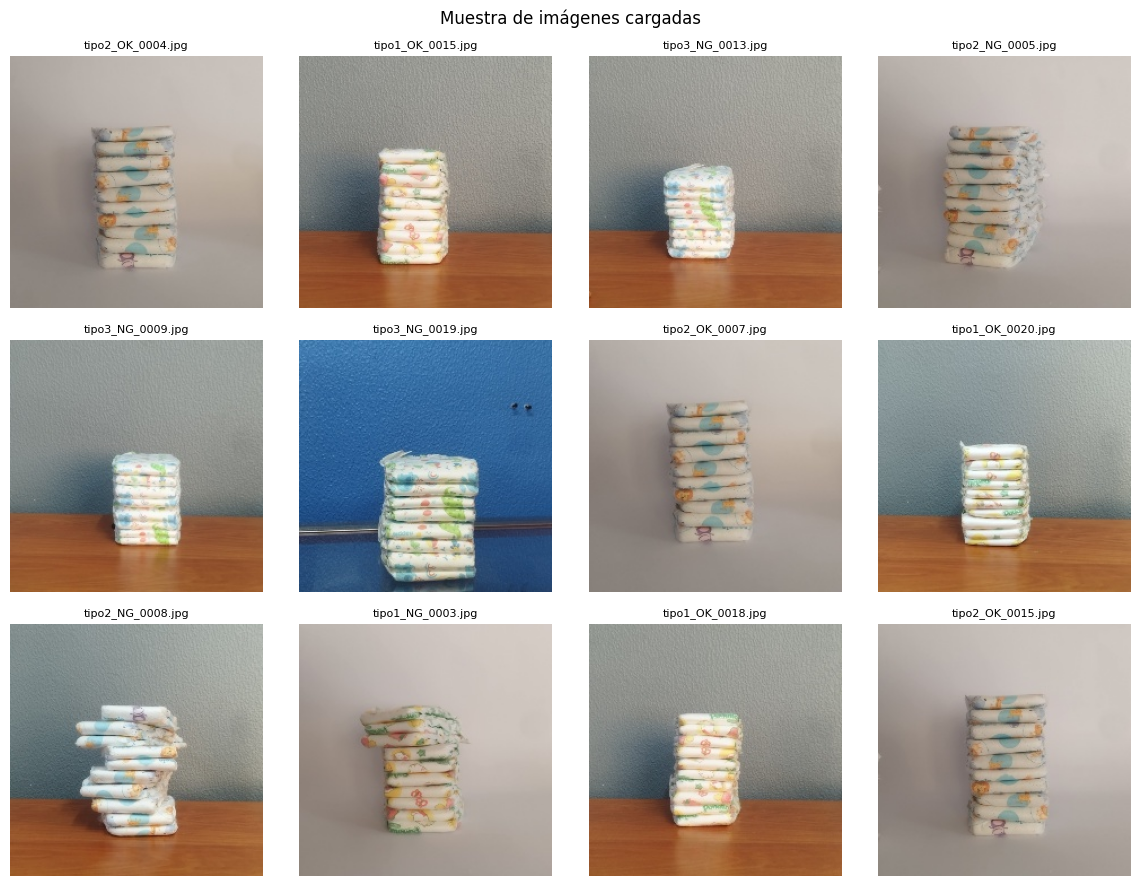

In [39]:
# Visualización — **Imágenes cargadas (grid de muestra)**
import math
import matplotlib.pyplot as plt
from pathlib import Path

def show_image_grid(df_paths, n=12, title="Muestra de imágenes cargadas"):
    if df_paths is None or len(df_paths)==0:
        print("No hay imágenes para mostrar. Ejecuta EDA primero.")
        return
    paths = df_paths["filepath"].tolist() if hasattr(df_paths, "columns") and "filepath" in df_paths.columns else list(df_paths)
    paths = paths[:n]
    cols = 4
    rows = math.ceil(len(paths)/cols) if paths else 1
    plt.figure(figsize=(cols*3, rows*3))
    for i, p in enumerate(paths):
        img = imread_rgb_unicode(p)
        plt.subplot(rows, cols, i+1)
        if img is not None:
            plt.imshow(img); plt.title(Path(p).name, fontsize=8)
        else:
            plt.text(0.5,0.5,"No legible", ha="center")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    if 'SAVE_FIGS' in globals() and SAVE_FIGS:
        _savefig("viz_grid_imagenes_cargadas")
    else:
        plt.show()

# Mostrar grid desde df_clean si existe; si no, desde df
to_show = None
if 'df_clean' in globals() and not df_clean.empty:
    to_show = df_clean.sample(min(12, len(df_clean)), random_state=RANDOM_SEED)
elif 'df' in globals() and not df.empty:
    to_show = df.sample(min(12, len(df)), random_state=RANDOM_SEED)

show_image_grid(to_show, n=12)


## 2. Importación de librerías Y UTILIDADES

In [40]:
# procesamiento de imágenes y visualización, combinando librerías de propósito general
import os, math, shutil, warnings, json, random
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image, ImageStat

try:
    import imagehash
except Exception: imagehash = None

try:
    import torch, torchvision
    from torchvision import transforms, models
except Exception:
    torch = None; torchvision = None

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from skimage.feature import hog

try:
    from imblearn.over_sampling import SMOTE
except Exception:
    SMOTE = None
    warnings.warn("imblearn no disponible; balanceo SMOTE deshabilitado.")

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

def _savefig(name):
    if not SAVE_FIGS:
        plt.show(); return
    out = OUTPUTS_DIR / f"{name}.png"
    plt.tight_layout(); plt.savefig(out, dpi=140)
    print(f"[Guardado] {out}")
    plt.show()


## 3. Escaneo de imágenes

In [8]:
# Escaneo de imágenes
def list_images_by_class(root: Path, img_exts=IMG_EXTS):
   # Recorre cada subcarpeta dentro de "root" (cada carpeta representa una clase/etiqueta)
    rows = []
    for cdir in sorted([p for p in root.iterdir() if p.is_dir()]):
        label = cdir.name
        for p in cdir.rglob("*"):
            if p.is_file() and p.suffix.lower() in img_exts:
                rows.append((str(p), label))
    return pd.DataFrame(rows, columns=["filepath","label"])

def imread_rgb_unicode(path_str):
    try:
        data = np.fromfile(path_str, dtype=np.uint8)
        bgr = cv2.imdecode(data, cv2.IMREAD_COLOR)
        if bgr is None: return None
        return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    except:
        try:
            with Image.open(path_str) as im:
                return np.array(im.convert("RGB"))
     # Devuelve un DataFrame con columnas "filepath" (ruta de la imagen) y "label" (clase)
        except: return None


## 4. PARTE 1 EDA

Total imágenes: 99


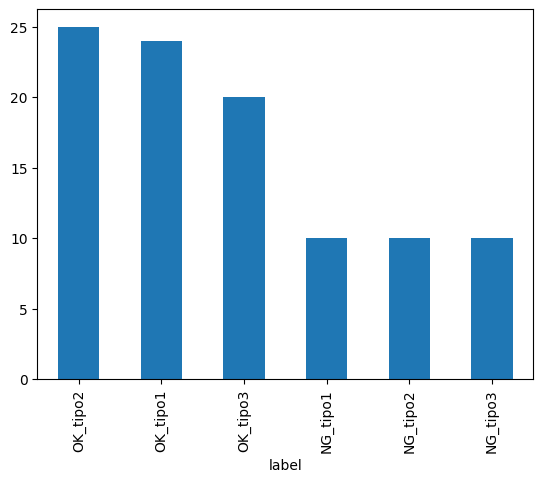

                          filepath     label        size
0  data/NG_tipo1/tipo1_NG_0003.jpg  NG_tipo1  (640, 640)
1  data/NG_tipo1/tipo1_NG_0010.jpg  NG_tipo1  (640, 640)
2  data/NG_tipo1/tipo1_NG_0006.jpg  NG_tipo1  (640, 640)
3  data/NG_tipo1/tipo1_NG_0005.jpg  NG_tipo1  (640, 640)
4  data/NG_tipo1/tipo1_NG_0004.jpg  NG_tipo1  (640, 640)


In [41]:
df = list_images_by_class(DATA_DIR, IMG_EXTS)
print("Total imágenes:", len(df))

# Balance clases
class_counts = df["label"].value_counts()
class_counts.plot(kind="bar"); plt.show()

# Métricas de imágenes
def basic_image_stats(path_str):
    try:
        with Image.open(path_str) as im:
            w,h = im.size
            return w,h
    except: return np.nan, np.nan

df["size"] = df["filepath"].apply(lambda x: basic_image_stats(x))
print(df.head())


[Guardado] outputs/class_distribution_pie_chart.png


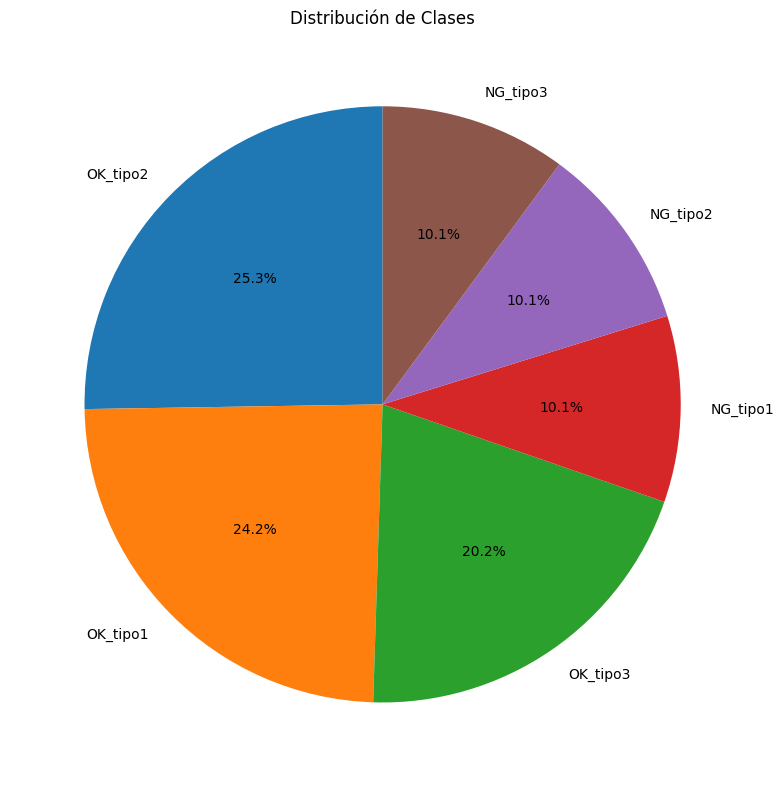

In [42]:
plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribución de Clases")
_savefig("class_distribution_pie_chart")

[Guardado] outputs/image_properties_correlation_heatmap.png


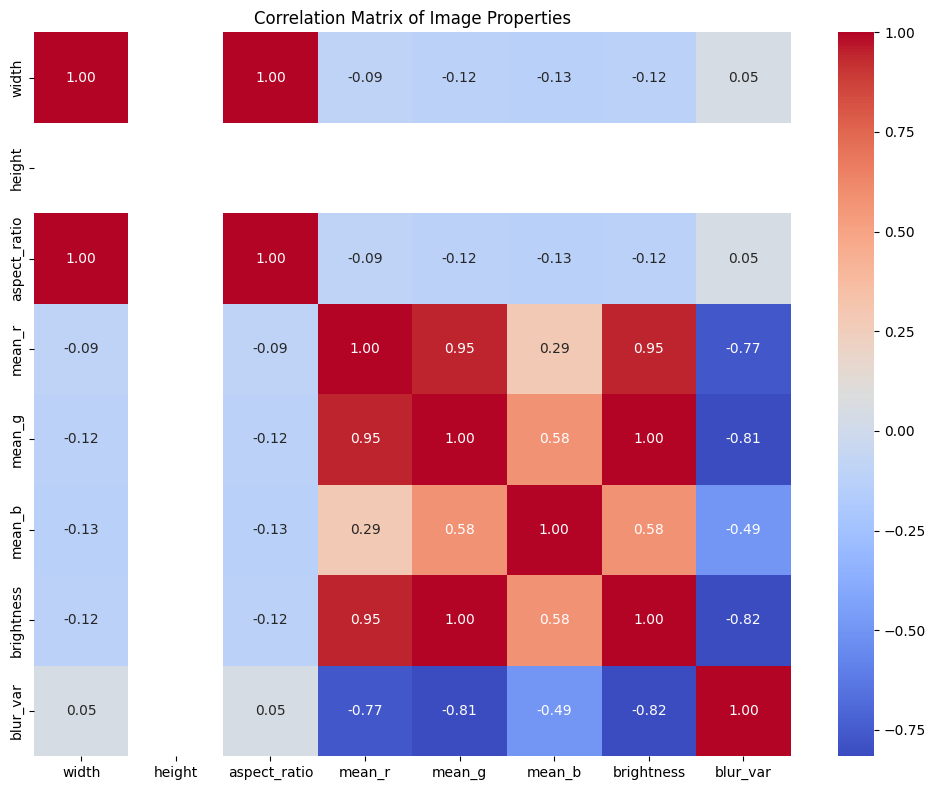

In [43]:
def calculate_image_properties(filepath):
    try:
        img = Image.open(filepath)
        w, h = img.size
        aspect_ratio = w / h if h != 0 else np.nan

        # Convert to RGB for color analysis
        img_rgb = img.convert("RGB")
        img_np = np.array(img_rgb)

        # Mean RGB
        mean_r, mean_g, mean_b = np.mean(img_np, axis=(0, 1))

        # Brightness (mean of all pixels)
        brightness = np.mean(img_np)

        # Blur (Variance of Laplacian)
        img_gray = cv2.cvtColor(np.array(img_rgb), cv2.COLOR_RGB2GRAY)
        blur_var = cv2.Laplacian(img_gray, cv2.CV_64F).var()

        return w, h, aspect_ratio, mean_r, mean_g, mean_b, brightness, blur_var
    except Exception as e:
        print(f"Error processing {filepath}: {e}")
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

# Calculate properties for each image
image_properties = df.apply(lambda row: calculate_image_properties(row['filepath']), axis=1)

# Create a DataFrame from the results
properties_df = pd.DataFrame(image_properties.tolist(), columns=['width', 'height', 'aspect_ratio', 'mean_r', 'mean_g', 'mean_b', 'brightness', 'blur_var'])

# Combine with original dataframe to keep labels
df_properties = pd.concat([df, properties_df], axis=1)

# Calculate correlation matrix
correlation_matrix = properties_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Image Properties")
_savefig("image_properties_correlation_heatmap")

## 5 PARTE 2 PIPELINE DE LIMPIEZA

In [44]:
import seaborn as sns

In [49]:
class DataCleaner:
    def __init__(self, resize_hw=(224,224)):
       # Inicializa la clase con el tamaño al que se redimensionarán las imágenes
        self.resize_hw = resize_hw

    def transform(self, df, dst_dir: Path):
       # Crea la carpeta de destino si no existe
        dst_dir.mkdir(parents=True, exist_ok=True)
        rows = [] # Lista para almacenar la nueva info de imágenes procesadas
        # Recorre cada fila del DataFrame (con rutas y etiquetas)
        for _, r in df.iterrows():
            img = imread_rgb_unicode(r["filepath"])
            if img is None: continue
            img_res = cv2.resize(img, self.resize_hw)
            out_folder = dst_dir / r["label"]; out_folder.mkdir(parents=True, exist_ok=True)
            out_path = out_folder / Path(r["filepath"]).name
            cv2.imwrite(str(out_path), cv2.cvtColor(img_res, cv2.COLOR_RGB2BGR))
            # Añade la ruta y etiqueta de la imagen procesada a la lista
            rows.append((str(out_path), r["label"]))
            # Devuelve un nuevo DataFrame con las rutas y etiquetas de las imágenes limpias
        return pd.DataFrame(rows, columns=["filepath","label"])

cleaner = DataCleaner()
df_clean = cleaner.transform(df, CLEAN_DIR)


## 6 PARTE 2 FEATURE ENGINEERING

In [46]:
def extract_color_hist(img, bins=32):
    hists = []
    # Recorre los 3 canales de color (B, G, R)
    for ch in range(3):
      # Calcula el histograma del canal con 'bins' intervalos en el rango [0, 256)
        h = cv2.calcHist([img],[ch],None,[bins],[0,256]).flatten()
        h /= (h.sum()+1e-9); hists.append(h)
        # Une los histogramas de los 3 canales en un solo vector de características
    return np.concatenate(hists)

def extract_hog(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return hog(gray, pixels_per_cell=(16,16), cells_per_block=(2,2))

rows = []
for _, r in df_clean.iterrows():
    img = imread_rgb_unicode(r["filepath"])
    if img is None: continue # Si no se pudo cargar, la omite
        # Extrae las features combinadas (ColorHist + HOG)
    feats = np.concatenate([extract_color_hist(img), extract_hog(img)])
    rows.append((feats, r["label"]))

# Imprime el número total de imágenes procesadas con extracción de características
print("Features extraídos:", len(rows))


Features extraídos: 99


[Guardado] outputs/pca_feature_visualization.png


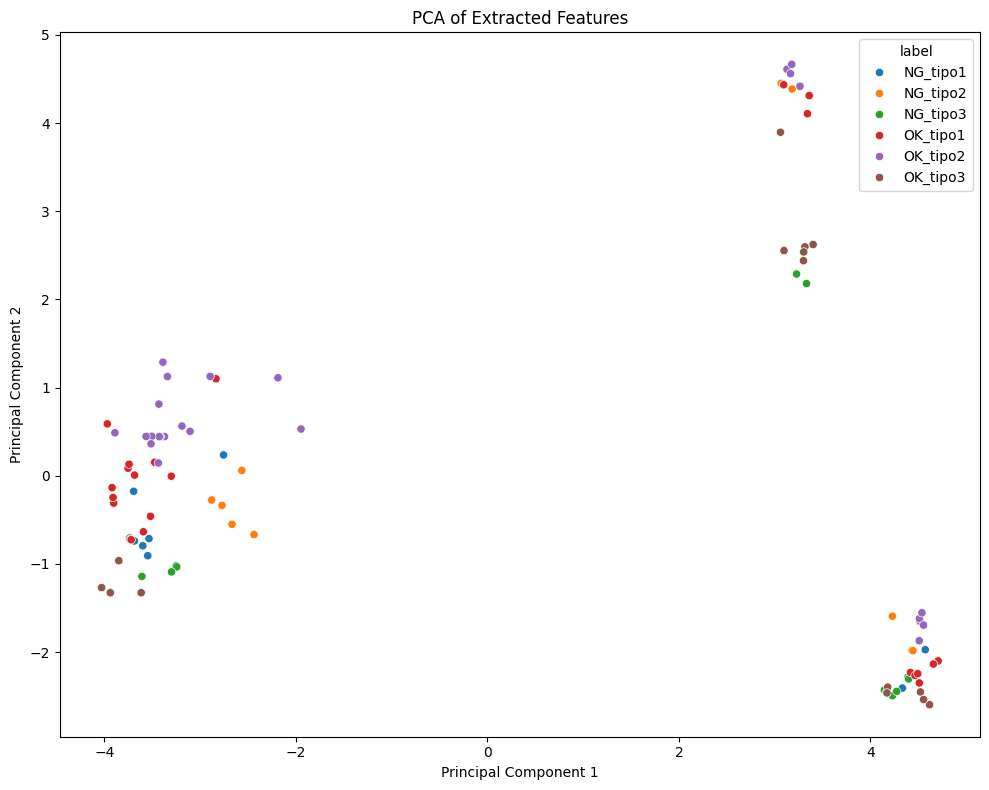

In [47]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming 'rows' contains (features, label) tuples
if len(rows) > 0:
    X = np.array([f for f,l in rows])
    y = np.array([l for f,l in rows])

    # Apply PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Create a DataFrame for easy plotting with seaborn
    pca_df = pd.DataFrame(data = X_pca, columns = ['pca_1', 'pca_2'])
    pca_df['label'] = y

    # Plot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='pca_1', y='pca_2', hue='label', data=pca_df, legend='full')
    plt.title('PCA of Extracted Features')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    _savefig("pca_feature_visualization")
else:
    print("No features to visualize. Please run the feature extraction step first.")

## 7 PARTE 2 BALANCE SMOTE & PCA

In [33]:
# Balanceo con SMOTE
if SMOTE and len(rows)>0:
    X = np.array([f for f,l in rows])
    y = np.array([l for f,l in rows])
    sm = SMOTE(random_state=RANDOM_SEED)
    Xb,yb = sm.fit_resample(X,y)
    print("Balanceo SMOTE:", Counter(yb))

# Split estratificado
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y)
print("Train:", len(X_train), "Test:", len(X_test))


Balanceo SMOTE: Counter({np.str_('NG_tipo1'): 25, np.str_('NG_tipo2'): 25, np.str_('NG_tipo3'): 25, np.str_('OK_tipo1'): 25, np.str_('OK_tipo2'): 25, np.str_('OK_tipo3'): 25})
Train: 79 Test: 20


In [34]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
preds = clf.predict(X_test)
print(classification_report(y_test, preds))


              precision    recall  f1-score   support

    NG_tipo1       1.00      0.50      0.67         2
    NG_tipo2       1.00      0.50      0.67         2
    NG_tipo3       1.00      0.50      0.67         2
    OK_tipo1       0.83      1.00      0.91         5
    OK_tipo2       0.83      1.00      0.91         5
    OK_tipo3       0.80      1.00      0.89         4

    accuracy                           0.85        20
   macro avg       0.91      0.75      0.78        20
weighted avg       0.88      0.85      0.83        20



[Guardado] outputs/pca_balanced_feature_visualization.png


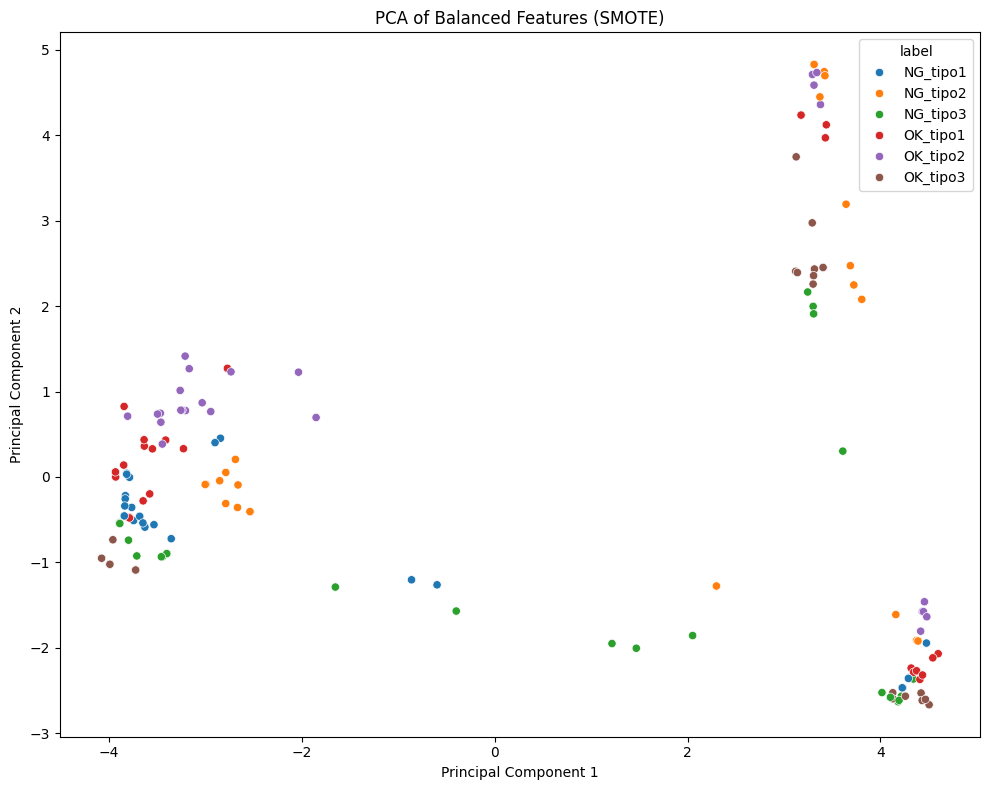

In [48]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming Xb and yb contain the balanced features and labels from the previous cell
if 'Xb' in globals() and 'yb' in globals() and len(Xb) > 0:
    # Apply PCA to the balanced data
    pca_balanced = PCA(n_components=2)
    Xb_pca = pca_balanced.fit_transform(Xb)

    # Create a DataFrame for easy plotting with seaborn
    pca_balanced_df = pd.DataFrame(data = Xb_pca, columns = ['pca_1', 'pca_2'])
    pca_balanced_df['label'] = yb

    # Plot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='pca_1', y='pca_2', hue='label', data=pca_balanced_df, legend='full')
    plt.title('PCA of Balanced Features (SMOTE)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    _savefig("pca_balanced_feature_visualization")
else:
    print("Balanced features (Xb, yb) not found. Please run the SMOTE balancing step first.")